In [7]:
import rebound
import numpy as np 
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit

# Scan dei parametri

### Scan su $V_x$
- Fissiamo $M_s$ grande
- distribuzione gaussiana di velocità in X

In [14]:
def heartbeat(sim_pointer):
    global v, cycle, bh_has_gone_too_far
    sim = sim_pointer.contents
    
    t = sim.t

    dt = boxL*nx/ncols/(Vx) #Particle spawning interval

    #Spawn particles
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vxs = np.random.normal(-Vx,sigmaVx,nrows)
        for j in range(nrows):
            sim.add(m=M/N,x=x,y=ys[j],vx=vxs[j],r=boxL/50)
        t = 0
        if sim.particles["BH"].x < xL:
            sim.stop

    v = np.append(v,sim.particles["BH"].vx) #save BH velocity
# Ms = np.linspace(10,100,10) #Massa gas
M = 100
# ms = np.linspace(10,100,10) #Massa BH
# Vxs = np.linspace(1,100,100) #Velocità relativa
m = 100
Vxs = np.logspace(2,-1,10)
sigmaVx = np.min(Vxs)
scanfolder = "scans/scanv2"
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
import pickle
picklefile = f'{scanfolder}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500 # aumenta se possibile
T = 10# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)
x0 = nx*boxL/2*0.01
xL = -x0
out = []

def line(x,a,q):
    return a*x+q

counter = 0
for Vx in Vxs:
    sim = rebound.Simulation()
    sim.heartbeat = heartbeat
    sim.widget(port=1267,size=(500,500))
    sim.configure_box(boxL,nx,ny)
    sim.boundary = "open"
    sim.gravity = "tree"
    sim.integrator = "leapfrog"
    sim.softening = 0.1
    sim.opening_angle2 = 1.5
    sim.collision = "none"

    #Add initial particles
    xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
    ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
    for x in xs:
        vxs = np.random.normal(-Vx,sigmaVx,nrows)
        for j in range(nrows):
            sim.add(m=M/N,x=x,y=ys[j],vx=vxs[j],r=boxL/50)
    sim.add(m=m,x=x0,y=0,vx=0,vy=0,hash="BH",r=boxL/10)
    v = []
    cycle = 0

    black_hole_has_gone_too_far = False
    # while sim.t<T:
    #     sim.steps(100)

    sim.integrate(T)

    ts = np.linspace(0,sim.t,len(v))
    cut = (ts>=0)
    popt, _ = curve_fit(line, ts[cut], v[cut])
    a = popt[0]

    title = f"M_gas = {M:0.0f} - M_BH = {m:0.2f} - Vx = {Vx:0.4f} - a = {a:0.3f}"

    if save_fig:
        fig, ax = plt.subplots()
        ax.plot(ts[cut],v[cut])
        ax.plot(ts[cut],line(ts[cut],*popt),'--r')
        ax.set_title(title)
        filename = f"{scanfolder}/{counter:05d}.png"
        fig.savefig(filename)
        plt.close()
    else:
        print(title)

    results = {
        "M": M,
        "m": m,
        "Vx": Vx,
        "a": a
    }

    out.append(results)
    if autosave:
        with open(picklefile, 'wb') as handle:
            pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

    counter += 1

if save:
    with open(picklefile, 'wb') as handle:
        pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

REBOUND Webserver listening on http://localhost:1267 ...


REBOUND Webserver listening on http://localhost:1267 ...


REBOUND Webserver listening on http://localhost:1267 ...


REBOUND Webserver listening on http://localhost:1267 ...


KeyboardInterrupt: 

### Scan logaritmico di $m$ e $Vx$

In [ ]:
def heartbeat(sim_pointer):
    global v, cycle
    sim = sim_pointer.contents
    t = sim.t

    dt = boxL*nx/ncols/(2*Vx) #Particle spawning interval

    #Spawn particles
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
        t = 0

    v = np.append(v,sim.particles["BH"].vx) #save BH velocity

# Ms = np.linspace(10,100,10) #Massa gas
Ms = [100]
# ms = np.linspace(10,100,10) #Massa BH
# Vxs = np.linspace(1,100,100) #Velocità relativa
ms = np.logspace(1,3,9)
Vxs = np.logspace(-1,3,100)
scanfolder = "scan2d"
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
import pickle
picklefile = f'{scanfolder}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500 # aumenta se possibile
T = 10# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)

out = []

def line(x,a,q):
    return a*x+q

counter = 0
for M in Ms:
    for m in ms:
        for Vx in Vxs:
            sim = rebound.Simulation()
            sim.heartbeat = heartbeat
            # sim.widget(port=1264,size=(1000,1000))
            sim.configure_box(boxL,nx,ny)
            sim.boundary = "open"
            sim.gravity = "tree"
            sim.integrator = "leapfrog"
            sim.softening = 0.1
            sim.opening_angle2 = 1.5
            sim.collision = "none"

            #Add initial particles
            xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
            ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
            for x in xs:
                for y in ys:
                    vx = -2*Vx
                    sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
            sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
            v = []
            cycle = 0

            sim.integrate(T)

            ts = np.linspace(0,sim.t,len(v))
            cut = (ts>=0)
            popt, _ = curve_fit(line, ts[cut], v[cut])
            a = popt[0]

            title = f"M_gas = {M:0.0f} - M_BH = {m:0.2f} - Vx = {Vx:0.4f} - a = {a:0.3f}"

            if save_fig:
                fig, ax = plt.subplots()
                ax.plot(ts[cut],v[cut])
                ax.plot(ts[cut],line(ts[cut],*popt),'--r')
                ax.set_title(title)
                filename = f"{scanfolder}/{counter:05d}.png"
                fig.savefig(filename)
                plt.close()
            else:
                print(title)

            results = {
                "M": M,
                "m": m,
                "Vx": Vx,
                "a": a
            }

            out.append(results)
            if autosave:
                with open(picklefile, 'wb') as handle:
                    pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

            counter += 1

if save:
    with open(picklefile, 'wb') as handle:
        pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Scan su $x_0$

In [138]:
def heartbeat(sim_pointer):
    global v, cycle
    sim = sim_pointer.contents
    t = sim.t

    dt = boxL*nx/ncols/(2*Vx) #Particle spawning interval

    #Spawn particles
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
        t = 0

    v = np.append(v,sim.particles["BH"].vx) #save BH velocity

# Ms = np.linspace(10,100,10) #Massa gas
M = 100
# ms = np.linspace(10,100,10) #Massa BH
# Vxs = np.linspace(1,100,100) #Velocità relativa
m = 100

scanfolder = "scanx050"
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
import pickle
picklefile = f'{scanfolder}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 100 # aumenta se possibile
T = 5# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)

Vxs = np.linspace(50,150,3)
Vxs = [100]
x0s = np.linspace(-nx*boxL/2*0.8,nx*boxL/2*0.8,50)

out = []

def line(x,a,q):
    return a*x+q

counter = 0
for x0 in x0s:
    for Vx in Vxs:
        sim = rebound.Simulation()
        sim.heartbeat = heartbeat
        sim.configure_box(boxL,nx,ny)
        sim.boundary = "open"
        sim.gravity = "tree"
        sim.integrator = "leapfrog"
        sim.softening = 0.1
        sim.opening_angle2 = 1.5
        sim.collision = "none"

        #Add initial particles
        xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        for x in xs:
            for y in ys:
                vx = -2*Vx
                sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/50)
        sim.add(m=m,x=x0,y=0,vx=0,vy=0,hash="BH",r=boxL/50)
        v = []
        cycle = 0

        sim.integrate(T)

        ts = np.linspace(0,sim.t,len(v))
        cut = (ts>=0)
        popt, _ = curve_fit(line, ts[cut], v[cut])
        a = popt[0]

        title = f"x0 = {x0} - Vx = {Vx:0.4f} - a = {a:0.3f}"

        if save_fig:
            fig, ax = plt.subplots()
            ax.plot(ts[cut],v[cut])
            ax.plot(ts[cut],line(ts[cut],*popt),'--r')
            ax.set_title(title)
            filename = f"{scanfolder}/{counter:05d}.png"
            fig.savefig(filename)
            plt.close()
        else:
            print(title)

        results = {
            "M": M,
            "m": m,
            "Vx": Vx,
            "a": a,
            "x0":x0
        }

        out.append(results)
        if autosave:
            with open(picklefile, 'wb') as handle:
                pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

        counter += 1

if save:
    with open(picklefile, 'wb') as handle:
        pickle.dump(out, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Analisi scan su $v$

[ 4.59338369  0.013369   -1.21897149]


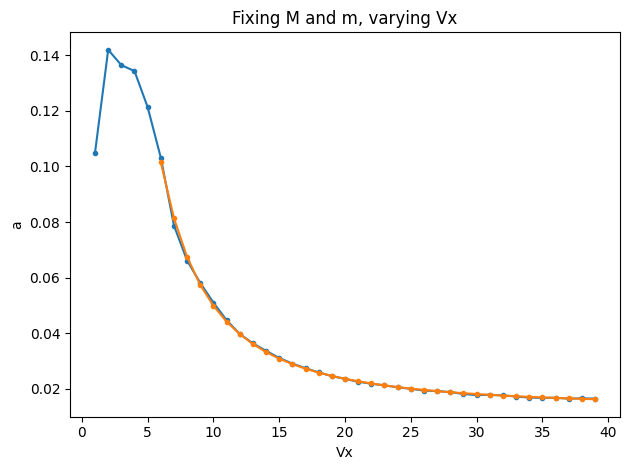

In [ ]:
scanfolder = "good_scan"
scanfolder = "scan20_100_6"
scanfolder = "scanv"
picklefile = f'{scanfolder}.pickle'
with open(picklefile, 'rb') as handle:
    out=pickle.load(handle)

# Mout = []
# fig, ax = plt.subplots(2)
# for Vx in Vxs:
#     cs = []
#     fixed1 = [results for results in out if results["Vx"] == Vx]
#     for m in ms:
#         fixed2 = [results for results in fixed1 if results["m"] == m]
#         a = np.array([results["a"] for results in fixed2])
#         xM = np.array([results["M"] for results in fixed2])

#         ax[0].plot(xM,-a,".-")
#         ax[0].set_xlabel("M")
#         ax[0].set_ylabel("a")

#         popt, _ = curve_fit(lambda x, c, q: c*x + q, xM, a)
#         c = popt[0]
#         print(f"{popt[1]*10000:0.2f}")
#         cs.append(c)
#     cs = np.array(cs)
#     ax[1].plot(ms,-cs,'.-')
#     ax[1].set_xlabel("m")
#     ax[1].set_ylabel("c")
# ax[0].set_title("Fixing Vx and m, varying M")
# ax[1].set_title("Angular coefficient")
# # ax[1].set_yscale("log")
# # ax[1].set_xscale("log")
# plt.tight_layout()
# plt.show()

def a_v(x,c0,c1,c2):
    return c0/(x-c2)**2+c1
fig, ax = plt.subplots()
for M in Ms:
    fixed_M = [results for results in out if results["M"] == M]
    for m in ms:
        fixed_m = [results for results in fixed_M if results["m"] == m]
        a = -np.array([results["a"] for results in fixed_m])
        xVx = np.array([results["Vx"] for results in fixed_m])
        cut = xVx > 5
        # cut = xVx > -1
        popt, _ = curve_fit(a_v,xVx[cut],a[cut])
        print(popt)
        ax.plot(xVx,a,".-")
        ax.plot(xVx[cut],a_v(xVx[cut],*popt),".-")
        ax.set_xlabel("Vx")
        ax.set_ylabel("a")
ax.set_title("Fixing M and m, varying Vx")
plt.tight_layout()

plt.show()

# fig, ax = plt.subplots(2)
# for Vx in Vxs:
#     cs = []
#     fixed_Vx = [results for results in out if results["Vx"] == Vx]
#     for M in Ms:
#         fixed_M = [results for results in fixed_Vx if results["M"] == M]
#         a = [results["a"] for results in fixed_M]
#         xm = [results["m"] for results in fixed_M]
#         ax[0].plot(xm,a,".-")
#         ax[0].set_xlabel("m")
#         ax[0].set_ylabel("a")
#         popt, _ = curve_fit(lambda x, c, q: c*x + q, xM, a)
#         c = popt[0]
#         cs.append(c)
#     cs = np.array(cs)
#     ax[1].plot(-cs,'.-')
#     ax[1].set_xlabel("m")
#     ax[1].set_ylabel("c")
# ax[0].set_title("Fixing Vx and M, varying m")
# plt.tight_layout()

plt.show()



### Analisi scan estensivo lineare $M$, $m$, $v$

In [ ]:
scanfolder = "scan10000"
picklefile = f'{scanfolder}.pickle'
with open(picklefile, 'rb') as handle:
    out=pickle.load(handle)

[0.10496268 0.14199804 0.13648211 0.13434495 0.1213478  0.1031634
 0.07871734 0.06613846 0.05805567 0.05098749 0.04466541 0.03970117
 0.03631717 0.03361533 0.03108819 0.02901766 0.02736997 0.02587159
 0.02454748 0.02353724 0.02251329 0.02181368 0.02120358 0.02050874
 0.01996408 0.01933446 0.01913222 0.01879807 0.01810474 0.01768941
 0.01781875 0.01759299 0.01719484 0.01682087 0.01671494 0.01674464
 0.01643156 0.01652535 0.01643646 0.01572973 0.01575846 0.01611254
 0.01553297 0.01549218 0.01534225 0.01526521 0.0155463  0.01552817
 0.0153666  0.01501976 0.01524042 0.01528743 0.01506025 0.01486891
 0.01492728 0.01498719 0.0146938  0.01470625 0.01452638 0.01454043
 0.01463238 0.01478018 0.01438239 0.01470857 0.01475823 0.01467689
 0.01462593 0.01490766 0.0141903  0.01435017 0.01482976 0.01432566
 0.01409713 0.01472209 0.01465165 0.01446726 0.01456821 0.01439344
 0.01472698 0.0138984  0.01431028 0.01446015 0.01401993 0.01446782
 0.01409883 0.0148041  0.01440122 0.01409427 0.01386748 0.01452

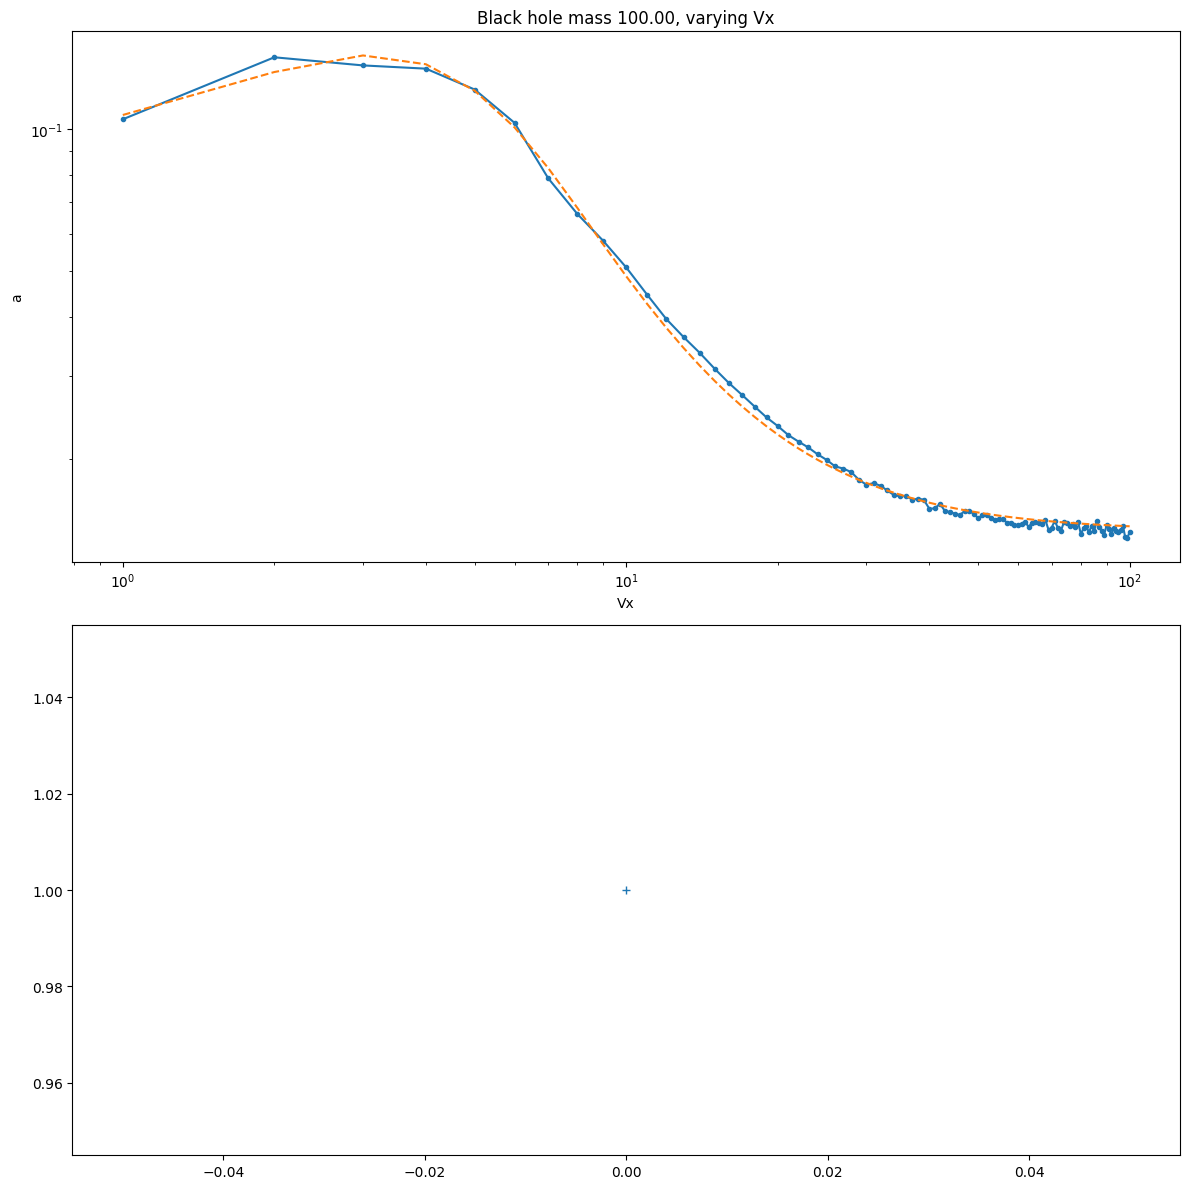

In [ ]:
Ms = np.linspace(10,100,10) #Massa gas
ms = np.linspace(10,100,10) #Massa BH
Vxs = np.linspace(1,100,100) #Velocità relativa
scanfolder = "scan10000"
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
import pickle
picklefile = f'{scanfolder}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500 # aumenta se possibile
T = 10# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)

def line(x,a,q):
    return a*x+q

def a_v(x,c0,c1,c2):
    return c0/(x-c2)**2+c1
def a_v_based(x,c0,c1,c3):
    from scipy.special import erf
    X = c3*x #c3 = 1/(sqrt(2)*sigma)
    return (erf(X)-2*X/np.sqrt(np.pi)*np.exp(-X**2))*c0/(x)**2+c1

def a_v_based_shift(x,c0,c1,c3,c2):
    from scipy.special import erf
    X = c3*x #c3 = 1/(sqrt(2)*sigma)
    return (erf(X)-2*X/np.sqrt(np.pi)*np.exp(-X**2))*c0/(x-c2)**2+c1
save_first = True
fig, axs = plt.subplots(2,figsize=(12,12))
ax, axq = axs
i = 0
Mfactor = []
for M in [Ms[-1]]:
    fixed_M = [results for results in out if results["M"] == M]
    for m in [ms[-1]]:
        fixed_m = [results for results in fixed_M if results["m"] == m]
        a = -np.array([results["a"] for results in fixed_m])
        if save_first:
            aa = a
            save_first = False
        Mfactor.append(np.mean(a/aa))
        xVx = np.array([results["Vx"] for results in fixed_m])
        cut = xVx > 0

        # cut = xVx > 
        popt1, _ = curve_fit(a_v_based,xVx[cut],a[cut],p0=[1,0.001,0.26])
        popt2, _ = curve_fit(a_v_based_shift,xVx[cut],a[cut],p0=np.r_[popt1,-1])
        # print(popt2)
        print(a)
        print(f"{1/(np.sqrt(2)*popt2[2])/np.sqrt(2)}")
        ax.plot(xVx,a,".-C0")
        # ax.plot(xVx[cut],a_v_based(xVx[cut],*popt1),"--C2")
        ax.plot(xVx[cut],a_v_based_shift(xVx[cut],*popt2),"--C1")
        ax.set_xlabel("Vx")
        ax.set_ylabel("a")
        ax.set_xscale("log")
        ax.set_yscale("log")

xfit = np.arange(len(Mfactor))

axq.plot(xfit,Mfactor,'+C0')

ax.set_title(f"Black hole mass {m:0.2f}, varying Vx")
plt.tight_layout()

plt.show()



### Analisi scan 10000 ma fit senza baseline

[ 0.54545873  0.01246944  0.91708748 -0.22025088]
[ 0.78185422  0.01326886  0.65502596 -0.04849554]
[ 1.19737219  0.01371574  0.52106122 -0.00349496]
[1.91084558 0.01425372 0.40375163 0.03938759]
[2.86695977 0.01589779 0.3308459  0.05907706]
[4.31844553 0.01777519 0.26962614 0.04892509]
[7.3845074  0.01825207 0.20470459 0.02926144]
[13.93411229  0.01804079  0.14469517  0.03665793]
[2.76457731e+01 1.67742123e-02 1.00388723e-01 3.89968511e-02]


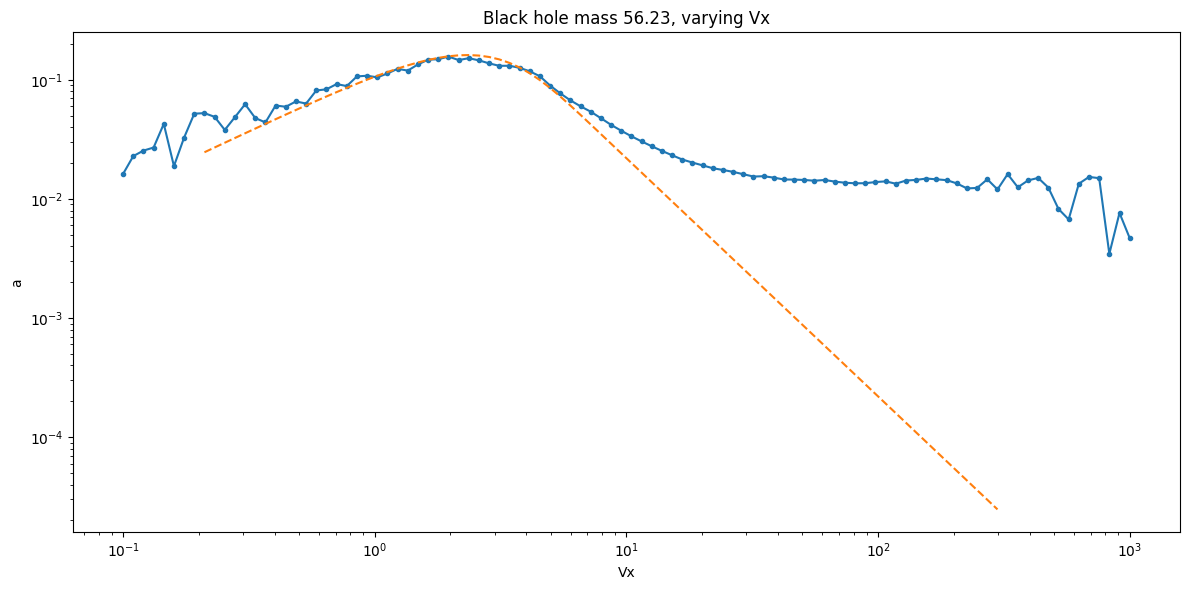

In [ ]:
M = 100
# ms = np.linspace(10,100,10) #Massa BH
# Vxs = np.linspace(1,100,100) #Velocità relativa
Vx = 100
scanfolder = "scan10000"
save_fig = True #spegni se non vuoi che plotti
save = True #occhio a sovrascrivere
autosave = True #autosalva ad ogni loop interno 

from pathlib import Path
Path(scanfolder).mkdir(parents=True,exist_ok=True)
import pickle
picklefile = f'{scanfolder}.pickle'

boxL = 10
nx, ny = 10, 5
np.random.seed(0)
N = 500 # aumenta se possibile
T = 10# aumenta se possibile
nrows = 20# aumenta se possibile
ncols = int(N/nrows)

def line(x,a,q):
    return a*x+q

def a_v(x,c0,c1,c2):
    return c0/(x-c2)**2+c1
def a_v_based(x,c0,c1,c3):
    from scipy.special import erf
    X = c3*x #c3 = 1/(sqrt(2)*sigma)
    return (erf(X)-2*X/np.sqrt(np.pi)*np.exp(-X**2))*c0/(x)**2+c1

def a_v_noc1(x,c0,c3):
    from scipy.special import erf
    X = c3*x #c3 = 1/(sqrt(2)*sigma)
    return (erf(X)-2*X/np.sqrt(np.pi)*np.exp(-X**2))*c0/(x)**2

def a_v_based_shift(x,c0,c1,c3,c2):
    from scipy.special import erf
    X = c3*x #c3 = 1/(sqrt(2)*sigma)
    return (erf(X)-2*X/np.sqrt(np.pi)*np.exp(-X**2))*c0/(x-c2)**2+c1
save_first = True

plot_i = 3
plot_all = 0

fig, axs = plt.subplots(1,figsize=(12,6))
ax = axs
i = 0
Mfactor = []
fixed_M = [results for results in out if results["M"] == M]
for i, m in enumerate(ms):
    fixed_m = [results for results in fixed_M if results["m"] == m]
    a = -np.array([results["a"] for results in fixed_m])
    xVx = np.array([results["Vx"] for results in fixed_m])
    cut = (xVx > 0.2) & (xVx < 300)

    popt0, _ = curve_fit(a_v_noc1,xVx[cut],a[cut],p0=[1,0.26])
    popt1, _ = curve_fit(a_v_based,xVx[cut],a[cut],p0=[1,0.001,0.26])
    popt2, _ = curve_fit(a_v_based_shift,xVx[cut],a[cut],p0=np.r_[popt1,-1])
    print(popt2)
    # print(f"{1/(np.sqrt(2)*popt2[2])}")
    if i==plot_i or plot_all:
        ax.plot(xVx,a,".-C0")
        ax.plot(xVx[cut],a_v_noc1(xVx[cut],*popt0),"--C1")
        # ax.plot(xVx[cut],a_v_based(xVx[cut],*popt1),"--C1")
        # ax.plot(xVx[cut],a_v_based_shift(xVx[cut],*popt2),"--C1")
        ax.grid()
        ax.set_xlabel("Vx")
        ax.set_ylabel("a")
        ax.set_xscale("log")
        ax.set_yscale("log")    
        ax.set_title(f"Black hole mass {m:0.2f}, varying Vx")
plt.tight_layout()

plt.show()



### Analisi scan $x_0$

In [3]:
scanfolder = "scanx050"
picklefile = f'{scanfolder}.pickle'
with open(picklefile, 'rb') as handle:
    out=pickle.load(handle)

[ 0.02727826  0.02484288  0.02244743  0.02053874  0.018536    0.01695109
  0.01493209  0.01336086  0.01168734  0.01046712  0.00900189  0.00788184
  0.00632274  0.00512907  0.00373943  0.00276685  0.00137463  0.00047542
 -0.0010215  -0.00194916 -0.0033771  -0.00432356 -0.00577761 -0.00689002
 -0.0084551  -0.00953466 -0.01107722 -0.01229588 -0.01401239 -0.01557234
 -0.01757927 -0.01915986 -0.02116831 -0.02305958 -0.02550686 -0.02797895]


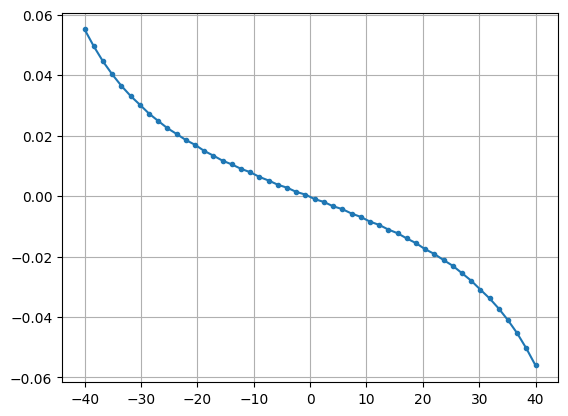

In [8]:
Vx = 100
nx = 10
boxL = 10
x0s = np.linspace(-nx*boxL/2*0.8,nx*boxL/2*0.8,50)
factor = -1/(+nx*boxL/2 +x0s)+1/(nx*boxL/2 - x0s)
a = np.array([res["a"] for res in out])

cut = (np.abs(x0s)<30)
print(a[cut])
fig, ax1 = plt.subplots()

ax1.plot(x0s,a,'.-')
ax1.grid()

plt.show()